In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

In [9]:
DATA_PATH = '../data/processed/stroke_processed.csv' 
SCALER_PATH = '../output/stroke_scaler.joblib'
ENCODER_PATH = '../output/stroke_encoder.joblib' # ADDED: We need the encoder!
MODEL_SAVE_PATH = '../output/stroke_cluster_model.joblib'

In [10]:
df = pd.read_csv(DATA_PATH)

In [11]:
for col in ['avg_glucose_level', 'bmi']:
    if col in df.columns:
        df[col] = np.log1p(df[col])

In [12]:
if 'Residence_type' in df.columns:
    df = df.drop(columns=['Residence_type'])

In [14]:
X = df.drop(columns=['stroke'])

In [15]:
CATEGORICAL_FEATURES = ['gender', 'ever_married', 'work_type', 'smoking_status']
NUMERICAL_FEATURES = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

In [16]:
encoder = joblib.load(ENCODER_PATH)
scaler = joblib.load(SCALER_PATH)

In [17]:
X_cat = encoder.transform(X[CATEGORICAL_FEATURES])
cat_feature_names = encoder.get_feature_names_out(CATEGORICAL_FEATURES)
X_cat_df = pd.DataFrame(X_cat, columns=cat_feature_names, index=X.index)

In [18]:
X_processed = pd.concat([X[NUMERICAL_FEATURES], X_cat_df], axis=1)

In [20]:
X_scaled = scaler.transform(X_processed)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_processed.columns)
print(f"Data shape for clustering: {X_scaled.shape}")

Data shape for clustering: (4254, 14)


In [21]:
inertia, silhouette_scores = [], []
K_range = range(2, 8)

In [22]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, kmeans.labels_))

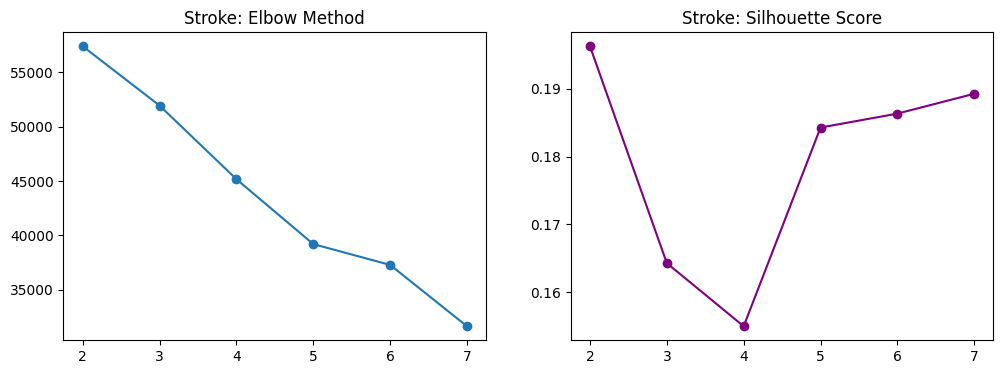

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertia, marker='o')
axes[0].set_title('Stroke: Elbow Method')
axes[1].plot(K_range, silhouette_scores, marker='o', color='purple')
axes[1].set_title('Stroke: Silhouette Score')
plt.show()

In [35]:
OPTIMAL_K = 5
final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)

In [36]:
df['Cluster'] = final_kmeans.fit_predict(X_scaled_df)

In [37]:
cluster_centroids = df.groupby('Cluster')[NUMERICAL_FEATURES].mean()
print("\n--- Stroke Risk Profiles (Numerical Averages) ---")
display(cluster_centroids)


--- Stroke Risk Profiles (Numerical Averages) ---


,age,hypertension,heart_disease,avg_glucose_level,bmi
Cluster,,,,,
0,52.275927,0.116578,0.064345,4.631465,3.440836
1,19.200000,0.000000,0.000000,4.549111,3.133192
2,32.523002,0.052058,0.026634,4.541929,3.365858
3,26.000000,0.000000,0.000000,4.972102,3.152736
4,62.129487,0.187179,0.106410,4.660718,3.424654


In [38]:
print("\n--- Stroke Risk Profiles (Categorical Modes) ---")
for col in CATEGORICAL_FEATURES:
    print(f"\nDominant {col} per cluster:")
    display(df.groupby('Cluster')[col].agg(lambda x: x.mode()[0]))


--- Stroke Risk Profiles (Categorical Modes) ---

Dominant gender per cluster:


Cluster
0    Female
1    Female
2    Female
3     Other
4    Female
Name: gender, dtype: str


Dominant ever_married per cluster:


Cluster
0    Yes
1     No
2     No
3     No
4    Yes
Name: ever_married, dtype: str


Dominant work_type per cluster:


Cluster
0          Private
1     Never_worked
2          Private
3          Private
4    Self-employed
Name: work_type, dtype: str


Dominant smoking_status per cluster:


Cluster
0       never smoked
1       never smoked
2       never smoked
3    formerly smoked
4       never smoked
Name: smoking_status, dtype: str

In [39]:
joblib.dump(final_kmeans, MODEL_SAVE_PATH)

['../output/stroke_cluster_model.joblib']

In [34]:
print(df['stroke'].value_counts())
print(df['stroke'].value_counts(normalize=True) * 100)

stroke
False    4007
True      247
Name: count, dtype: int64
stroke
False    94.1937
True      5.8063
Name: proportion, dtype: float64
